In [70]:
import numpy as np
import pandas as pd
#import umap
import matplotlib.pyplot as plt
import scanpy as sc
import squidpy as sq
from anndata import AnnData
from muon import prot as pt
from sklearn import preprocessing
import seaborn as sns
input_dir = 'input_files'
output_fig = 'figures'

Here I load the spatial data, which consists of the protein intensity per cell, and the geometry location of the cell. I use the cell type annotation from AnnoSpat

read intensities ( protein level per cell)

In [59]:
intensities = pd.read_csv(input_dir+'/all_data_intensities.csv',index_col=0)
intensities.index = intensities.index.astype(str)
intensities['ROI'] = pd.to_numeric(intensities.ROI.str[-3:])#make ROI numeric
columns_to_extract = intensities.columns.difference(['ROI', 'source_file'])
intensities_protein = intensities[columns_to_extract]#contains only numeric values (intensities)

The variable`regions` contains the spatial properties of the cells. Cell geometry and location is obtained from ilastik and CellProfiler

In [60]:
regions = pd.read_csv(input_dir+'/all_data_regions.csv',index_col=0)
regions.head()

,area,centroid-0,centroid-1,major_axis_length,minor_axis_length,eccentricity,source_file
0,16,1.500000,1.500000,4.472136,4.472136,0.000000,Leap002_003
1,26,1.730769,6.346154,6.458965,5.156497,0.602197,Leap002_003
2,73,2.082192,15.698630,16.540737,5.932868,0.933460,Leap002_003
3,62,1.838710,35.532258,14.916095,5.917155,0.917950,Leap002_003
4,23,0.956522,45.608696,9.966303,3.081719,0.950993,Leap002_003


N. of cells by experiments

<Figure size 432x288 with 0 Axes>

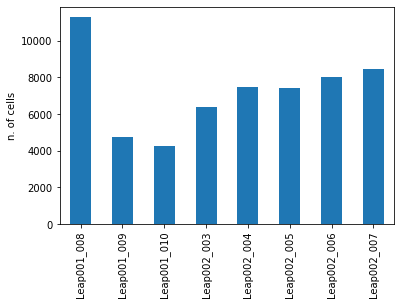

<Figure size 432x288 with 0 Axes>

In [10]:
intensities.source_file.value_counts().sort_index().plot(kind = 'bar')
plt.ylabel('n. of cells')
plt.figure()

In [62]:
intensities.source_file.value_counts().index

Index(['Leap001_008', 'Leap002_007', 'Leap002_006', 'Leap002_004',
       'Leap002_005', 'Leap002_003', 'Leap001_009', 'Leap001_010'],
      dtype='object')

Load the expert curated signature table

<AxesSubplot:>

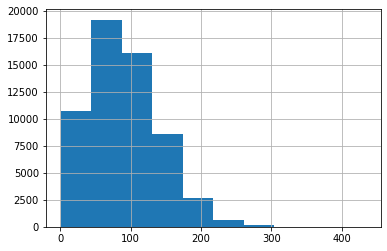

In [11]:
regions.area.hist()

#pt.pp.clr(adata)

cell type annotation comes from AnnoSpat

In [12]:
labels = pd.read_csv('output/trte_labels_ELM_IMC_T1D_AnnoSpat.csv')
num_labels = pd.read_csv('output/trte_labels_numericLabels_ELM_IMC_T1D_AnnoSpat.csv')
mapper = dict(zip(num_labels.label,labels.label))#convert numeric labels to cell types


Using the analysis of [squidpy](https://squidpy.readthedocs.io/en/stable/notebooks/tutorials/tutorial_read_spatial.html) 

In [163]:
adata = AnnData(intensities_protein, obsm={"spatial": regions[['centroid-0', 'centroid-1']].values})
adata.obs['ROI'] =  intensities.ROI

<ipython-input-163-8e8831625758>:1: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  adata = AnnData(intensities_protein, obsm={"spatial": regions[['centroid-0', 'centroid-1']].values})


In AnnoSpat authors log-transform the counts, and normalise every cell to have $L_2$ norm 1

In [165]:

#“centered log ratio"
adata = AnnData(intensities_protein, obsm={"spatial": regions[['centroid-0', 'centroid-1']].values})
adata.obs['AnnoSpat'] = pd.Categorical(labels.label.values.astype(str))
#“centered log ratio"
sc.pp.log1p(adata)

#sc.pp.normalize_total(adata)# it uses the l1 norm, we like the l2 instead
adata.X = preprocessing.normalize(adata.X, norm='l2')
#sc.pp.pca(adata,n_comps=25)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata)
adata.obs['ROI'] =  intensities.ROI

<ipython-input-165-92202a89b3f9>:2: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  adata = AnnData(intensities_protein, obsm={"spatial": regions[['centroid-0', 'centroid-1']].values})


In [27]:
adata.obs

,AnnoSpat,leiden,ROI
0,18,0,7
1,18,2,7
2,18,9,7
3,18,9,7
4,0,0,7
...,...,...,...
58026,15,5,2
58027,13,5,2
58028,13,5,2
58029,13,5,2


take picture of a specific ROI, do not mix ROIs together

/home/giuseppe/anaconda3/lib/python3.8/site-packages/anndata/_core/anndata.py:1235: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


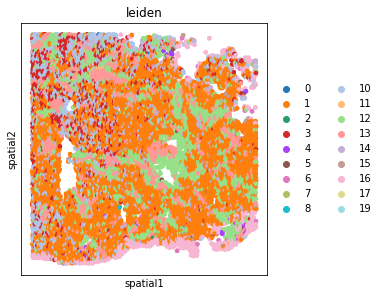

In [45]:
sq.pl.spatial_scatter(adata[adata.obs.ROI ==1], shape=None, color="leiden", size=50)


In [47]:
sq.pl.spatial_scatter?

/home/giuseppe/anaconda3/lib/python3.8/site-packages/anndata/compat/_overloaded_dict.py:106: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.data[key] = value
<ipython-input-73-368c678da19b>:2: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.
  plt.tight_layout()


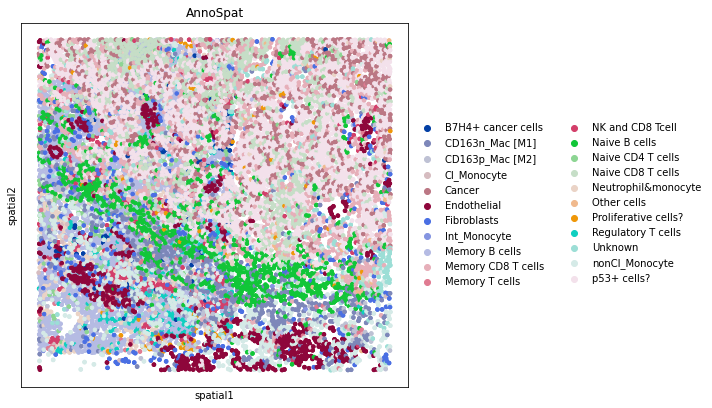

In [73]:
sq.pl.spatial_scatter(adata[adata.obs.ROI ==2], shape=None, color="AnnoSpat", size=50,figsize = (10,10))
plt.tight_layout()
#plt.savefig(output_fig+'/spatial_ROI2.png')

Below I compute the dot product between the dotplot matrix ( average expression of a protein in a cluster) and the signature matrix. It gives a value between [-1,1] so that the highest the better

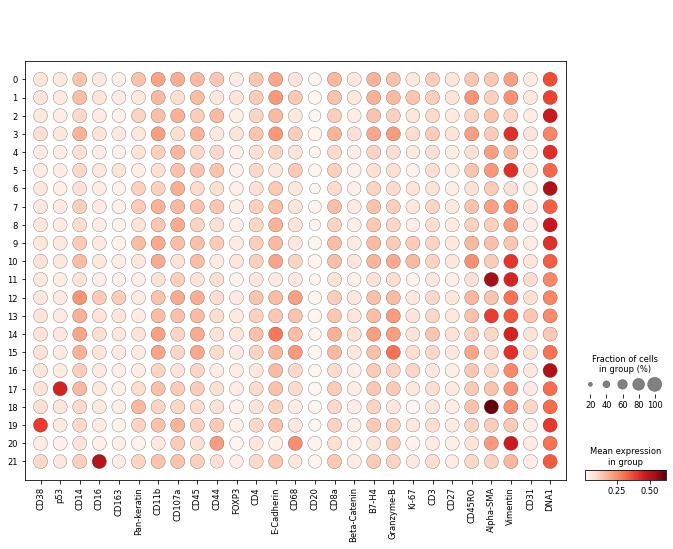

<AxesSubplot:ylabel='leiden'>

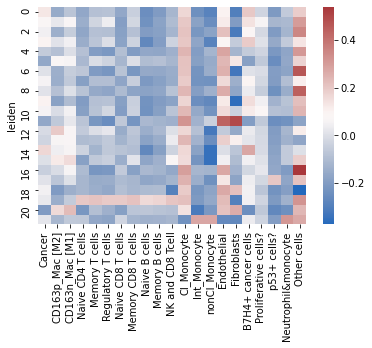

In [30]:
#sc.pl.dotplot(adata, var_names = marker_list, groupby = "AnnoSpat")
def create_dotplot(adata,groupby):
    '''
    compute the correlation between the dotplot and the manually curated marker table
    '''
    dotplot = sc.pl.dotplot(adata, var_names = marker_list, groupby = groupby,return_fig=True)
    dotplot.show()
    dot_color = dotplot.dot_color_df
    corr = (dot_color-(dot_color.max(axis = 0)/2))@signature_sign.loc[marker_list]
    return corr
corr_leiden = create_dotplot(adata,'leiden')
sns.heatmap(corr_leiden,cmap='vlag')

In the case of the AnnoSpat, I expect that the element in the diagonal are the heighest of the column

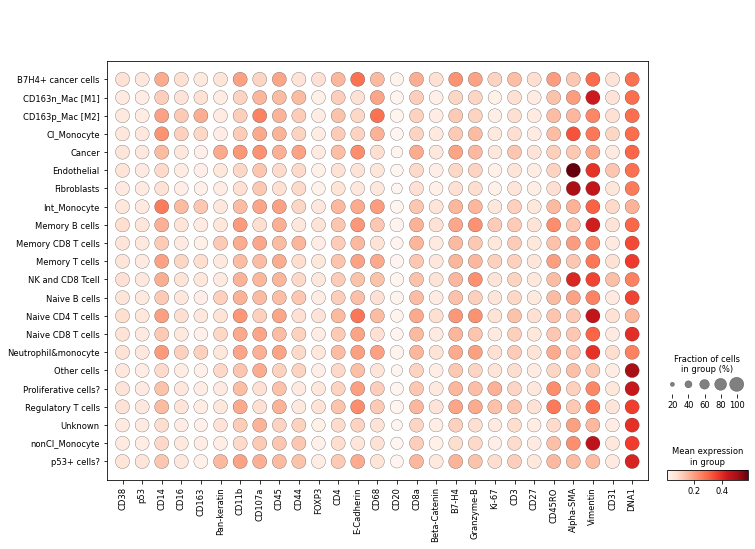

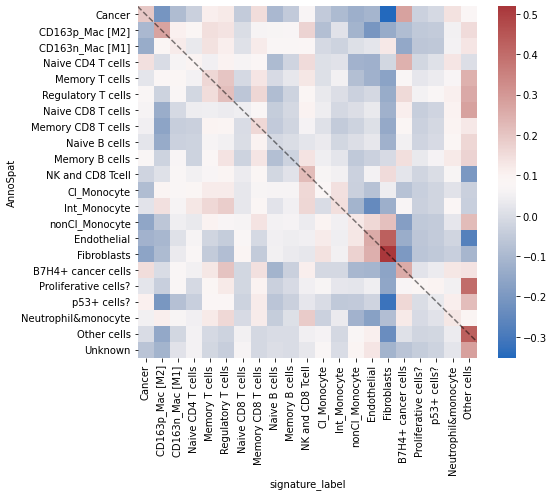

In [121]:
corr_anno = create_dotplot(adata,'AnnoSpat')
plt.figure(figsize = (8,7))
sns.heatmap(corr_anno.loc[list(signature_sign.columns)+['Unknown'],signature_sign.columns],cmap='vlag')
plt.xlabel('signature_label')

plt.plot([0,len(adata.obs.AnnoSpat.value_counts())],[0,len(adata.obs.AnnoSpat.value_counts())],'k--',alpha = 0.5)
plt.tight_layout()
#plt.savefig(output_fig+'/label_overlap.png')

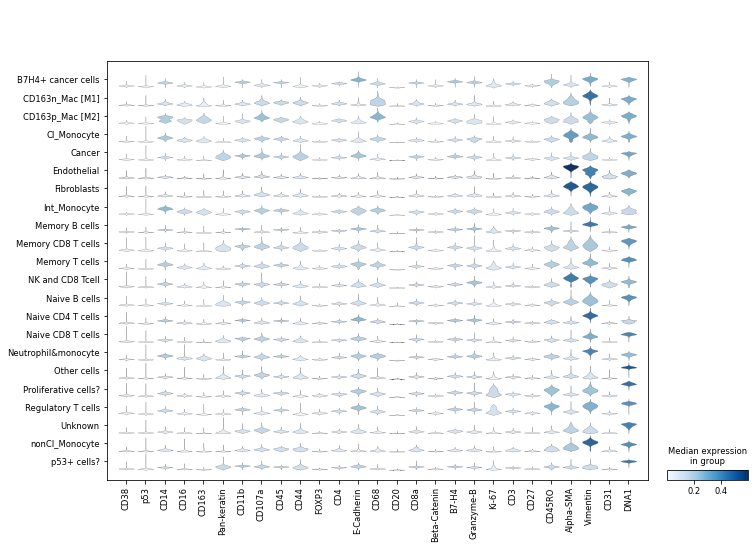

<Figure size 432x288 with 0 Axes>

In [81]:
sc.pl.stacked_violin(adata, marker_list, groupby='AnnoSpat', rotation=90,save='.png')
plt.tight_layout()
#plt.savefig(output_fig+'/violin.png')

mapping from cell type label to name

In [ ]:
pd.DataFrame.from_dict(mapper,orient='index',columns=['Cell_type']).sort_index()#for AnnoSpat, this is the mapping from cell type label to name

In [213]:

## for the named clusters, do the markers (and is there fast way of checking)

## for each marker gene that appears at all, make a set of violin plots for all
## cell types that have that marker in the list, and look if higher in "high" and 
## lower in "low" (and label somewhere on the fig which should be high/low)

## importing the signature file and then check are they "high"
signature = pd.read_csv('processed_files/signature.csv',index_col=0)

## with the unnamed ones, can we try to manually annotate them 
## for the leiden, which AnnoSpat labels are most frequent? 
## (maybe a cross-correlation matrix?)




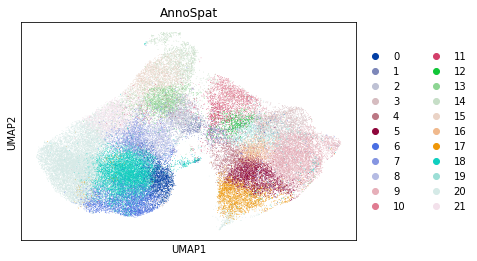

In [53]:
sc.pl.umap(adata,color='AnnoSpat')

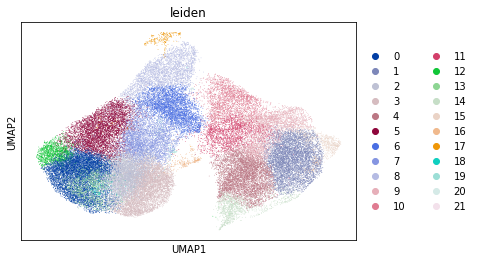

In [10]:
sc.pl.umap(adata,color='leiden')

  0%|          | 0/1000 [00:00<?, ?/s]

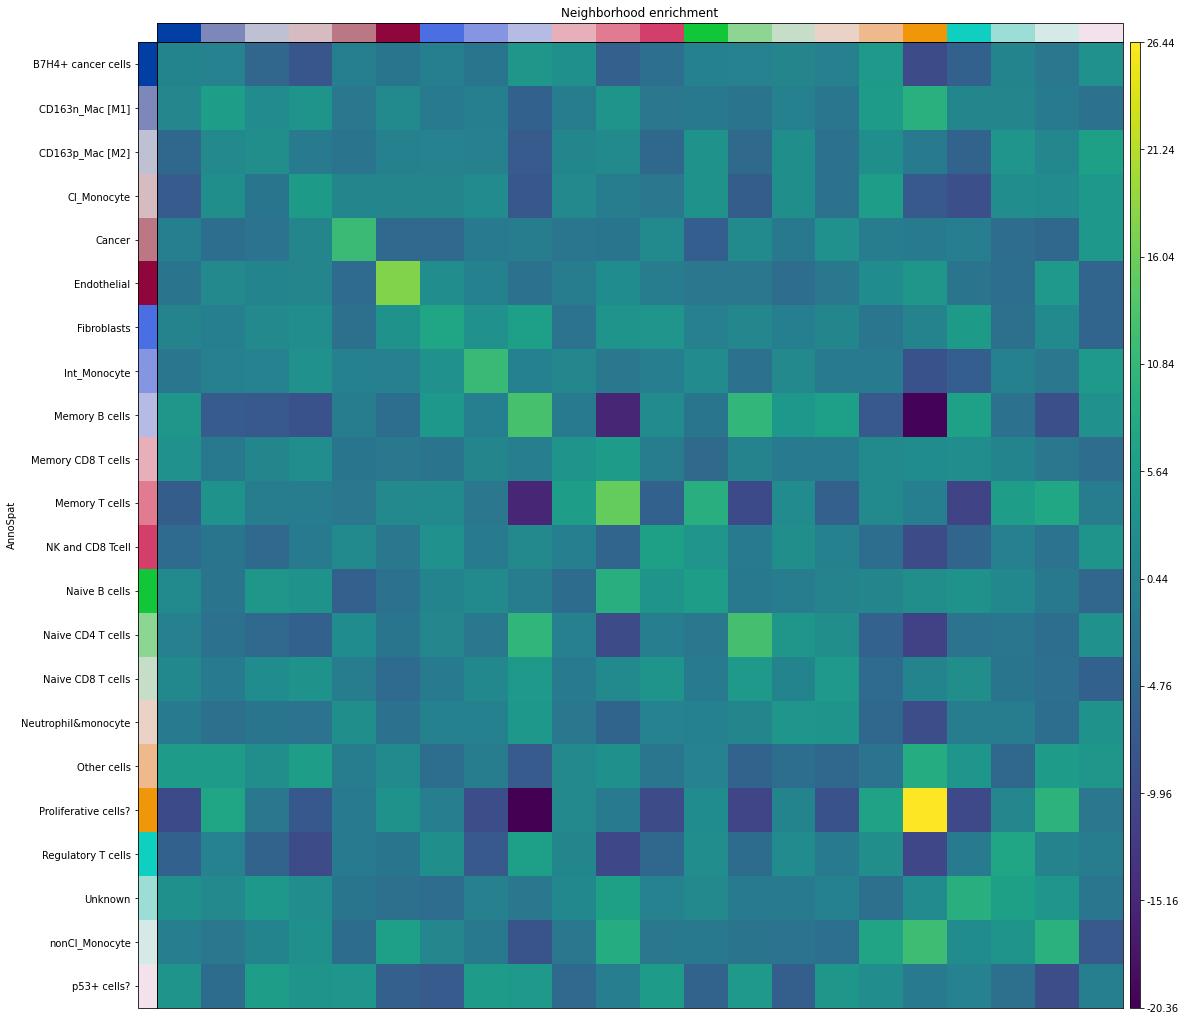

In [123]:
sq.gr.spatial_neighbors(adata)
sq.gr.nhood_enrichment(adata, cluster_key='AnnoSpat')
#sq.pl.nhood_enrichment(adata, cluster_key='AnnoSpat',save='/enrichment.png')
sq.pl.nhood_enrichment(adata, cluster_key='AnnoSpat')

In [132]:
adata.obs.AnnoSpat.value_counts().index

CategoricalIndex(['Other cells', 'p53+ cells?', 'Memory B cells',
                  'Naive CD8 T cells', 'Regulatory T cells', 'Unknown',
                  'Proliferative cells?', 'nonCI_Monocyte', 'Cancer',
                  'Fibroblasts', 'Endothelial', 'Memory CD8 T cells',
                  'Naive CD4 T cells', 'Naive B cells', 'NK and CD8 Tcell',
                  'Neutrophil&monocyte', 'CD163n_Mac [M1]', 'Memory T cells',
                  'B7H4+ cancer cells', 'CD163p_Mac [M2]', 'CI_Monocyte',
                  'Int_Monocyte'],
                 categories=['B7H4+ cancer cells', 'CD163n_Mac [M1]', 'CD163p_Mac [M2]', 'CI_Monocyte', ..., 'Regulatory T cells', 'Unknown', 'nonCI_Monocyte', 'p53+ cells?'], ordered=False, dtype='category')

In [209]:
adata.uns

OverloadedDict, wrapping:
	OrderedDict([('log1p', {'base': None}), ('neighbors', {'connectivities_key': 'connectivities', 'distances_key': 'distances', 'params': {'n_neighbors': 15, 'method': 'umap', 'random_state': 0, 'metric': 'euclidean'}}), ('umap', {'params': {'a': 0.5830300205483709, 'b': 1.334166992455648}}), ('leiden', {'params': {'resolution': 1, 'random_state': 0, 'n_iterations': -1}})])
With overloaded keys:
	['neighbors'].

In [172]:
ROI_1 = adata[adata.obs.ROI ==1]
sq.gr.co_occurrence(ROI_1, cluster_key="AnnoSpat",n_splits=1)


  0%|          | 0/1 [00:00<?, ?/s]

/home/giuseppe/anaconda3/lib/python3.8/site-packages/anndata/compat/_overloaded_dict.py:106: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.data[key] = value


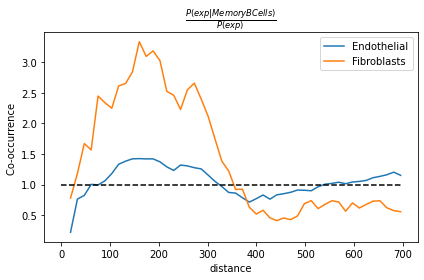

In [288]:
a = np.array(ROI_1.obs['AnnoSpat'].cat.categories)
x = ROI_1.uns['AnnoSpat_co_occurrence']['interval'][1:]
plt.plot(x,np.squeeze(np.squeeze(ROI_1.uns['AnnoSpat_co_occurrence']['occ'][np.arange(len(a))[a=='Memory B cells']])[a == 'Endothelial']),label = 'Endothelial')
#ROI_1.uns['AnnoSpat_co_occurrence']['interval']
plt.plot(x,np.squeeze(np.squeeze(ROI_1.uns['AnnoSpat_co_occurrence']['occ'][np.arange(len(a))[a=='Memory B cells']])[a == 'Fibroblasts']),label = 'Fibroblasts')
plt.plot([0,x.max()],[1,1], 'k--')
plt.legend()
plt.xlabel('distance')
plt.ylabel('Co-occurrence ')
plt.title('$\\frac{P(exp|Memory B Cells)}{P(exp)}$')
plt.tight_layout()
#plt.savefig(output_fig+'/co_occurrence_End_Fib.png')

In [237]:
ROI_1.obs.AnnoSpat.value_counts()

Regulatory T cells      2340
Proliferative cells?    2074
Memory T cells          1078
B7H4+ cancer cells      1016
Naive CD4 T cells        792
Memory B cells           700
NK and CD8 Tcell         667
CI_Monocyte              547
Neutrophil&monocyte      510
Int_Monocyte             451
CD163p_Mac [M2]          357
Other cells              284
Endothelial              110
Naive CD8 T cells         57
Unknown                   57
p53+ cells?               49
Naive B cells             43
nonCI_Monocyte            42
Cancer                    40
Memory CD8 T cells        37
CD163n_Mac [M1]           24
Fibroblasts               10
Name: AnnoSpat, dtype: int64

array([8])

ERROR: Unable to fetch palette, reason: 'AnnoSpat_colors'. Using `None`.


<ipython-input-286-89bac40a46e5>:7: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.
  plt.tight_layout()


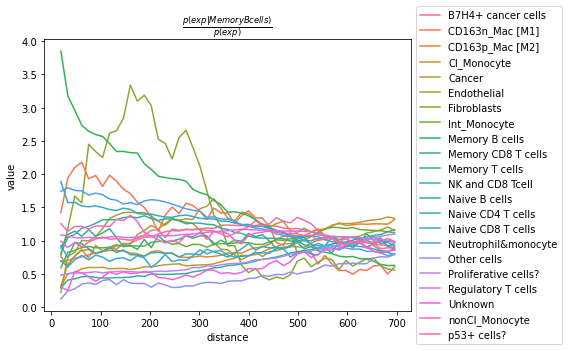

In [286]:
sq.pl.co_occurrence(
    ROI_1,
    cluster_key="AnnoSpat",
    clusters=['Memory B cells'],
    figsize=(8, 5),
)
plt.tight_layout()
plt.savefig(output_fig+'/co_occurrence_all.png')

ERROR: Unable to fetch palette, reason: 'AnnoSpat_colors'. Using `None`.


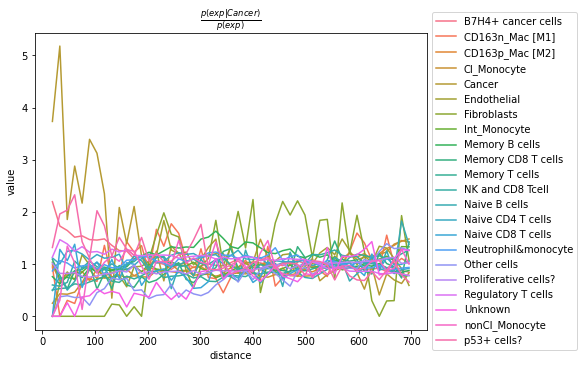

In [185]:
sq.pl.co_occurrence(
    ROI_1,
    cluster_key="AnnoSpat",
    clusters=['Cancer'],
    figsize=(8, 5),
)

In [205]:
cell_type_totals = pd.read_csv('../IMC_Segmentation_results/IMCCelltypeResults/CellTypeTotals.csv')
cell_type_totals

,Image,CellType,Total,Density,Total_highProb,Density_highProb,Area_highProb,Max_probability_area,Max_probability_area_percentage
0,Leap001_ROI_001,Cancer,140.336744,1.223648e-04,0.000000,0.000000,0.000000,0,0.000000
1,Leap001_ROI_001,CD163p_Mac..M2.,1726.340928,1.505260e-03,31.445619,0.000027,0.000172,37,0.003226
2,Leap001_ROI_001,CD163n_Mac..M1.,6245.313083,5.445519e-03,1.636302,0.000001,0.000013,4,0.000349
3,Leap001_ROI_001,Naive.CD4.T.cells,18.398982,1.604275e-05,3.855173,0.000003,0.000022,7,0.000610
4,Leap001_ROI_001,Memory.T.cells,6.909340,6.024509e-06,1.678131,0.000001,0.000010,2,0.000174
...,...,...,...,...,...,...,...,...,...
3292,Leap033_ROI_004_CEN,B7H4..cancer.cells,247.867192,2.250519e-04,140.656241,0.000128,0.000657,0,0.000000
3293,Leap033_ROI_004_CEN,Proliferative.cells.,692.715283,6.289533e-04,106.335940,0.000097,0.000371,137,0.012439
3294,Leap033_ROI_004_CEN,p53..cells.,475.107114,4.313752e-04,82.992746,0.000075,0.000312,0,0.000000
3295,Leap033_ROI_004_CEN,Neutrophil.monocyte,0.615505,5.588498e-07,0.000000,0.000000,0.000000,0,0.000000


In [204]:
intensities[['source_file','ROI']].value_counts()

source_file  ROI
Leap001_008  1      11285
Leap002_007  2       8471
Leap002_006  3       7998
Leap002_004  5       7486
Leap002_005  4       7418
Leap002_003  7       6399
Leap001_009  2       4741
Leap001_010  3       4233
dtype: int64